In [1]:
import tifffile
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
image = tifffile.imread('/dtu-compute/msaca/sliceA_xray_pc/output/cache/sino_004/sino_00075.tiff')

In [3]:
from multiprocessing import Pool, cpu_count

# path to the folder containing the tiff files
folder = "/dtu-compute/msaca/sliceA_xray_pc/output/cache/sino_004"

# generate filenames (sino_00000.tiff ... sino_00700.tiff)
filenames = [os.path.join(folder, f"sino_{i:05d}.tiff") for i in range(701)]

def load_tiff(path):
    return tifffile.imread(path)

if __name__ == "__main__":
    with Pool(16) as pool:
        images_xa = pool.map(load_tiff, filenames)
images_xa = np.stack(images_xa)


In [48]:
#!pip install fabio
import fabio
proj_compressed = tifffile.imread('/dtu-compute/msaca/sliceA_xray_pc/compressed_XA_004_/compressed_XA_004_4500.tiff')
proj_c_flat = tifffile.imread('/dtu-compute/msaca/sliceA_xray_pc/compressed_XA_004_/obeam/refHST6000.tiff')
proj_full = fabio.open('/dtu-compute/msaca/sliceA_xray_pc/HA900_3um_mars_rock_002_/HA900_3um_mars_rock_002_4500.edf')   
proj_flat = fabio.open('/dtu-compute/msaca/sliceA_xray_pc/HA900_3um_mars_rock_002_/refHST6000.edf')  
proj_dark = fabio.open('/dtu-compute/msaca/sliceA_xray_pc/HA900_3um_mars_rock_002_/dark.edf')   

temp = -np.log((proj_full.data[:,1000:]-proj_dark.data[:,1000:])/(proj_flat.data[:,1000:]-proj_dark.data[:,1000:] + 0.001))
temp2 = -np.log((proj_full.data[:,:100]-proj_dark.data[:,:100])/(proj_flat.data[:,:100]-proj_dark.data[:,:100] + 0.001))

print(temp.mean())
print(temp2.mean())
a = temp.mean()-temp2.mean()
print(a)
print(a/0.16)

0.2276962395109807
0.17189091245814184
0.05580532705283886
0.3487832940802429


In [8]:
print(proj_flat.data[50:1910,:2060].shape)
print(proj_compressed.data.shape)

(1860, 2048)
(790, 1748)


0.22447162570304752
31735.896218463055
0.11274424730816192


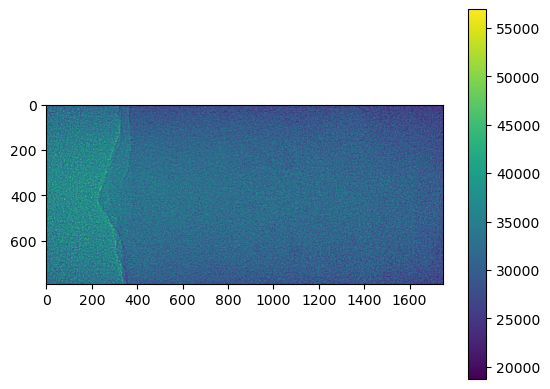

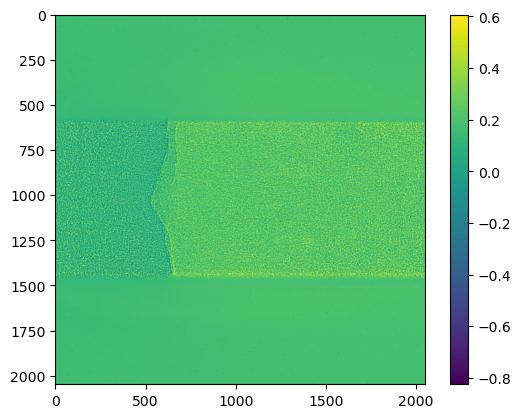

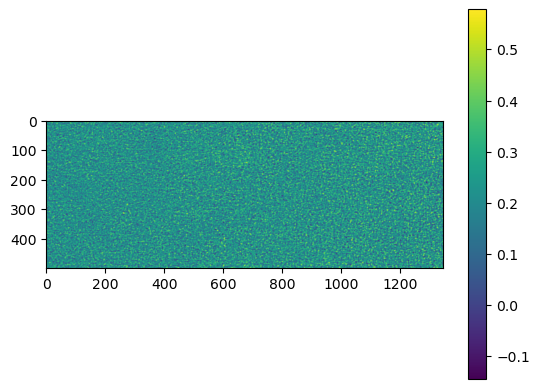

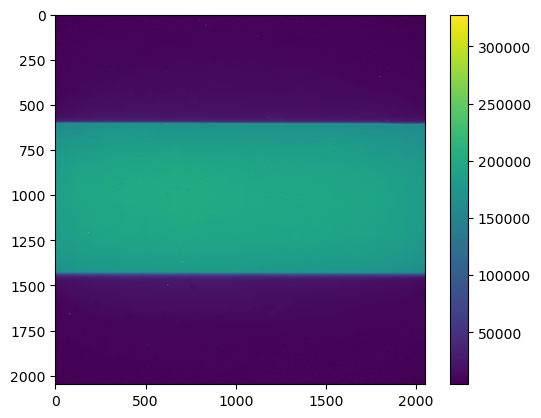

In [ ]:
print(np.mean(temp[750:1250,700:]))
print(np.mean(proj_compressed[:,400:]))
print(np.mean(temp[750:1250,:400]))

plt.imshow(proj_compressed)
plt.colorbar()
plt.show()
plt.imshow(temp*1.0)
plt.colorbar()
plt.show()
plt.imshow(temp[750:1250,700:]*1.0)
plt.colorbar()
plt.show()
plt.imshow(proj_flat.data*1.0)
plt.colorbar()
plt.show()


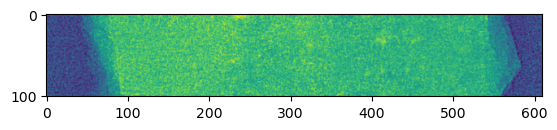

10.24127


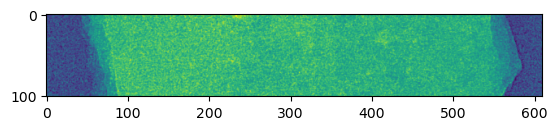

10.283544


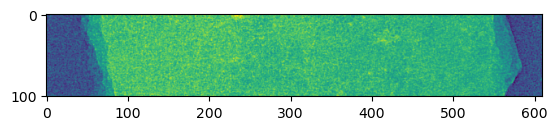

10.350251


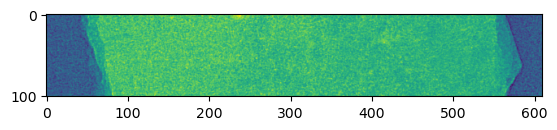

10.463827


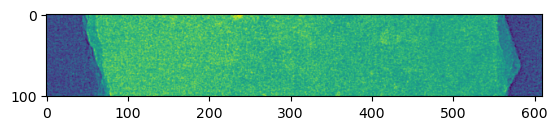

10.45815


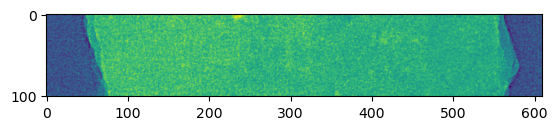

10.532875


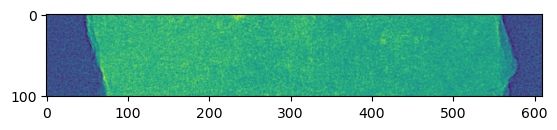

10.502783


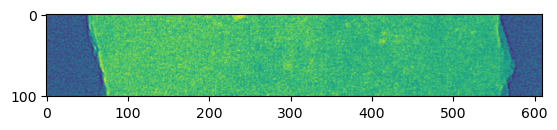

10.534812


In [56]:

for i in range(1300,1700,50):
    plt.imshow(images_xa[100:-100:5,i,100:-100:5])
    plt.show()
    print(np.mean(images_xa[100:-100:5,i,100:-100:5]))

In [ ]:



from multiprocessing import Pool, cpu_count

# path to the folder containing the tiff files
folder = "/dtu-compute/msaca/sliceA_neutron_psi/output/cache"

# generate filenames (sino_00000.tiff ... sino_00700.tiff)
filenames = [os.path.join(folder, f"spot_cleaned_{i:05d}.tiff") for i in range(400,801)]

def load_tiff(path):
    return tifffile.imread(path)

if __name__ == "__main__":
    with Pool(16) as pool:
        images_na = pool.map(load_tiff, filenames)

images_na = np.stack(images_na)

0.02408229
0.016098429
0.019251917
0.018119313
0.016040815
0.015906276
0.0008596853
0.007089863
0.0145017225
0.021126248
0.016222548
0.024875829
0.021663323
0.01909124
0.021885887
0.016531566
0.026043504
0.019427083
0.032845166
0.022682795


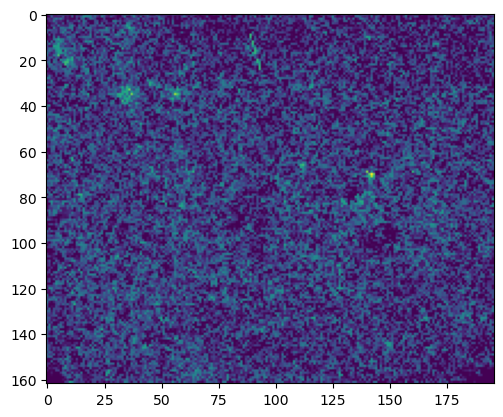

In [44]:
plt.imshow(images[200,400:-650:5,500:-400:5])
plt.clim([0, 0.1])
for i in range(0,400,20):
    print(np.mean(images[i,400:-650:5,500:-400:5]))

0.01086846


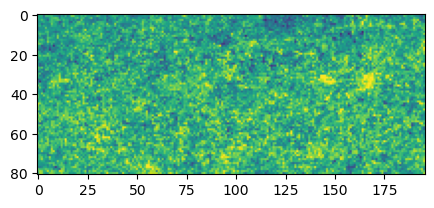

1.0394795


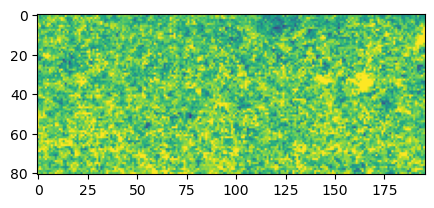

1.7145461


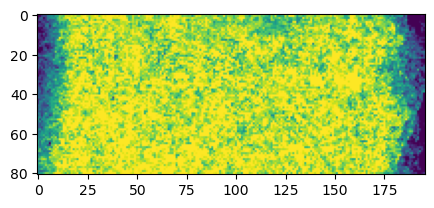

1.1517531


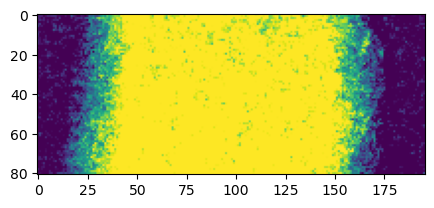

3.1140552


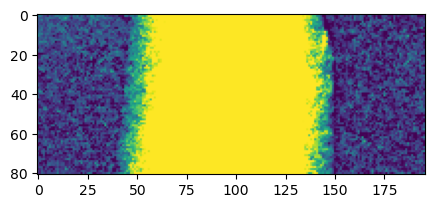

1.9819504


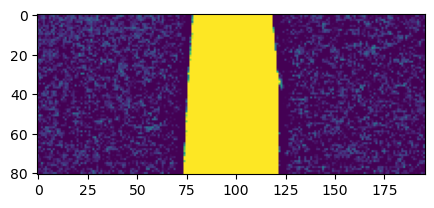

0.75687057


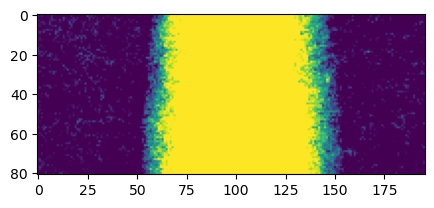

2.7434175


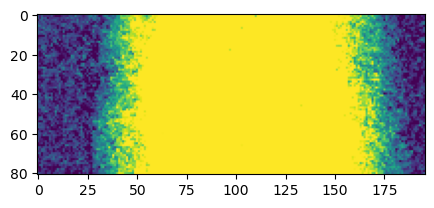

1.9516556


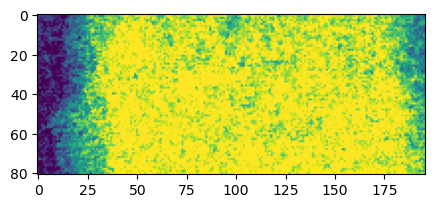

0.72292715


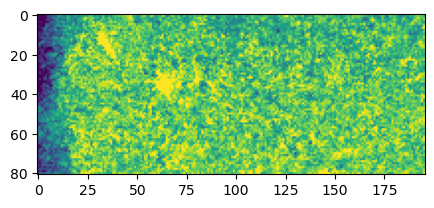

0.7511844


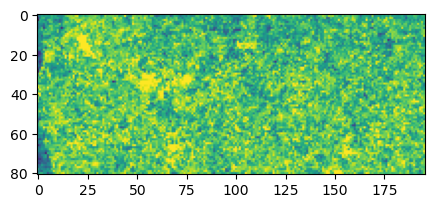

0.7068033


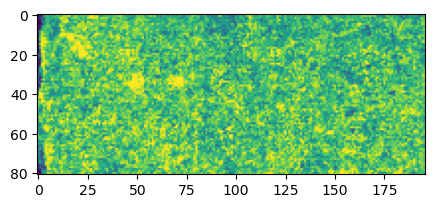

0.58676916


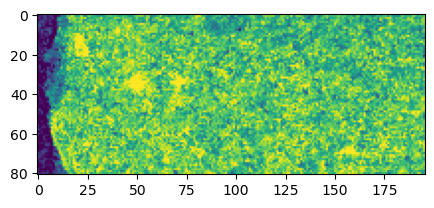

1.4627395


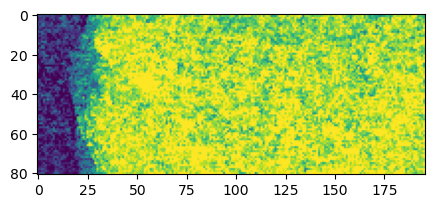

2.795166


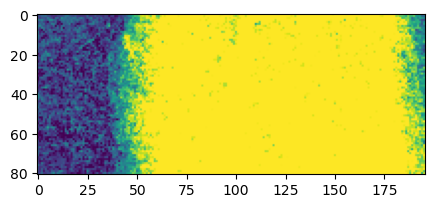

1.6429455


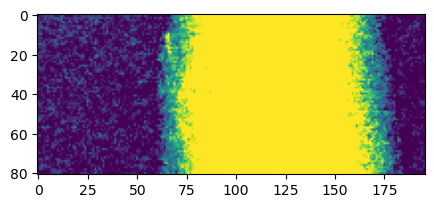

2.432791


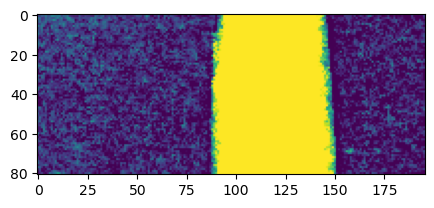

2.1322207


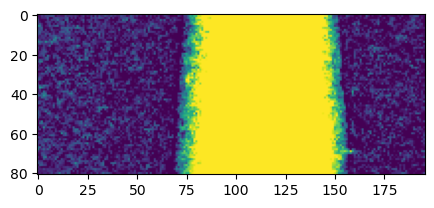

3.0861878


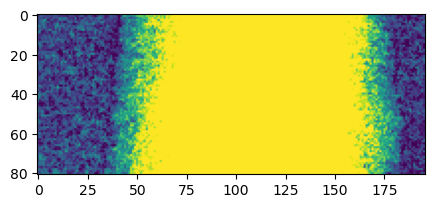

1.3844786


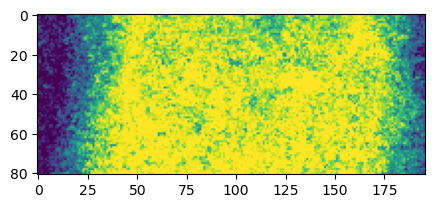

In [19]:
images = np.stack(images)

for i in range(00,1000,50):
    example = images[:,i]
    plt.figure(figsize=(5,5))
    plt.imshow(example[::5,400:-500:5])
    plt.clim([-5,3])
    print(np.mean(example[:,400:-500]))
    plt.show()

In [10]:
print(np.shape(images))

(701, 3000, 3248)
